In [60]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import os
import operator

load_dotenv()



True

In [61]:
model= ChatOpenAI(api_key=os.getenv("api_key"), temperature=0,model="gpt-4o-mini")

In [62]:
class EvaluationSchema(BaseModel):
    score: int = Field(description="An integer score from 1 to 10 evaluating the quality of the essay.",ge=0, le=10)
    feedback: str = Field(description="A brief explanation for the given score.")

In [63]:
structured_model=model.with_structured_output(EvaluationSchema)

In [64]:
essay="""
**Artificial Intelligence in India: Opportunities, Challenges, and the Road Ahead**

Artificial Intelligence (AI) has emerged as one of the most transformative technologies of the 21st century, reshaping economies, governance, education, healthcare, and everyday life. In India, a country marked by vast population diversity, rapid digitization, and complex socio-economic challenges, AI holds immense promise. From improving public service delivery to boosting industrial productivity and fostering innovation, AI is increasingly seen as a key driver of India’s future growth. At the same time, its adoption raises critical questions related to ethics, employment, data privacy, and inclusivity. This essay explores the evolution, applications, opportunities, and challenges of AI in India, along with its future prospects.

India’s engagement with AI has accelerated significantly over the past decade. The growth of digital infrastructure such as Aadhaar, Digital India, UPI, and widespread smartphone usage has created massive volumes of data, which form the backbone of AI systems. Recognizing the strategic importance of AI, the Government of India has taken several initiatives to promote its development and responsible use. Policy frameworks such as the National Strategy for Artificial Intelligence, often referred to as “AI for All,” emphasize using AI for inclusive growth and social good. Institutions like NITI Aayog, along with research bodies, startups, and academic institutions, are playing a crucial role in shaping India’s AI ecosystem.

One of the most impactful applications of AI in India is in the healthcare sector. With a large population and limited access to quality healthcare in rural and remote areas, AI-driven solutions can bridge critical gaps. AI tools are being used for early disease detection, medical imaging, predictive analytics, and personalized treatment. For example, machine learning algorithms can help detect diseases such as tuberculosis, cancer, and diabetic retinopathy at early stages, often with accuracy comparable to medical experts. Telemedicine platforms powered by AI chatbots and diagnostic tools are also expanding healthcare access to underserved communities.

In agriculture, which employs a significant portion of India’s workforce, AI is transforming traditional practices. AI-based systems help farmers make informed decisions regarding crop selection, soil health, irrigation, and pest control. Satellite imagery, drones, and predictive analytics enable precision farming, reducing input costs and increasing yields. By analyzing weather patterns and market trends, AI can also help farmers plan better and minimize losses due to climate variability. Such applications are particularly important in a country where agriculture is highly dependent on monsoons and vulnerable to climate change.

The education sector in India is also benefiting from AI-driven innovations. Personalized learning platforms use AI algorithms to adapt content to individual students’ learning styles and pace. Automated assessment tools, virtual tutors, and intelligent content recommendations are improving learning outcomes and expanding access to quality education. In a country with a large youth population, AI-enabled education can play a vital role in skill development and workforce readiness, especially in emerging fields such as data science, robotics, and software engineering.

AI is increasingly being adopted in governance and public administration to improve efficiency, transparency, and citizen engagement. Chatbots and virtual assistants are used by government departments to provide information and services to citizens. AI-based data analytics help policymakers identify trends, detect fraud, and optimize resource allocation. Smart city initiatives leverage AI for traffic management, waste management, energy efficiency, and public safety. These applications contribute to better urban planning and improved quality of life for citizens.

India’s private sector and startup ecosystem have been instrumental in driving AI innovation. Indian startups are developing AI solutions across domains such as fintech, e-commerce, logistics, cybersecurity, and language translation. Fintech companies use AI for credit scoring, fraud detection, and customer service, expanding financial inclusion. Given India’s linguistic diversity, AI-based natural language processing tools for Indian languages are particularly significant, enabling wider digital participation. Global technology companies are also investing in AI research and development centers in India, recognizing the country’s talent pool and market potential.

Despite its vast potential, the adoption of AI in India faces several challenges. One major concern is the impact of AI on employment. Automation and AI-driven systems may displace certain types of jobs, particularly in low-skill and repetitive tasks. While AI is also expected to create new job opportunities, there is a risk of skill mismatches. Addressing this requires large-scale reskilling and upskilling initiatives to prepare the workforce for an AI-driven economy.

Data privacy and ethical concerns represent another significant challenge. AI systems rely heavily on large datasets, often containing sensitive personal information. Ensuring data protection, preventing misuse, and avoiding algorithmic bias are critical issues. In a diverse society like India, biased AI systems could reinforce existing social inequalities. Therefore, transparent, accountable, and ethical AI frameworks are essential to build public trust and ensure fair outcomes.

Infrastructure and access gaps also limit AI adoption, particularly in rural areas. Reliable internet connectivity, quality data, and computing resources are not uniformly available across the country. Bridging the digital divide is crucial to ensure that the benefits of AI reach all sections of society, not just urban and affluent populations.

Looking ahead, the future of AI in India is both promising and challenging. With its large pool of engineers, scientists, and entrepreneurs, India has the potential to become a global hub for AI innovation. Continued investment in research, education, and digital infrastructure will be key. Equally important is the development of robust regulatory and ethical frameworks that balance innovation with social responsibility.

In conclusion, AI has the potential to play a transformative role in India’s development journey. By addressing critical challenges in healthcare, agriculture, education, governance, and industry, AI can contribute to inclusive growth and improved quality of life. However, realizing this potential requires careful planning, ethical considerations, and a strong focus on human-centric development. If harnessed responsibly, AI can become a powerful tool in shaping a more equitable, efficient, and prosperous India.

"""

In [65]:
prompt=f"Evaluate the language quality of the following essay on a scale of 1 to 10, where 1 is poor and 10 is excellent. Provide a feedback and assign a score out of 10.\n {essay}"
structured_model.invoke(prompt)

EvaluationSchema(score=9, feedback='The essay is well-structured, informative, and covers a wide range of applications and implications of AI in India. The language is clear and professional, with appropriate use of technical terms. It effectively balances the opportunities and challenges associated with AI, providing a comprehensive overview. Minor improvements could be made in terms of conciseness and avoiding repetition, but overall, it demonstrates a high level of quality.')

In [66]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    avg_score: float
    individual_scores: Annotated[list[int],operator.add]       # [8], [7], [9] -> [8,7,9]

In [67]:
def evaluate_language(state:UPSCState):
    prompt=f"Evaluate the language quality of the following essay on a scale of 1 to 10, where 1 is poor and 10 is excellent. Provide a feedback and assign a score out of 10.\n {state['essay']}"
    result=structured_model.invoke(prompt)

    return {'language_feedback': result.feedback, "individual_scores": [result.score]}

In [68]:
def evaluate_analysis(state:UPSCState):
    prompt=f"Evaluate the analytical depth of the following essay on a scale of 1 to 10, where 1 is poor and 10 is excellent. Provide a feedback and assign a score out of 10.\n {state['essay']}"
    result=structured_model.invoke(prompt)

    return {'analysis_feedback': result.feedback, "individual_scores": [result.score]}

In [69]:
def evaluate_thought(state:UPSCState):
    prompt=f"Evaluate the clarity of thought the following essay on a scale of 1 to 10, where 1 is poor and 10 is excellent. Provide a feedback and assign a score out of 10.\n {state['essay']}"
    result=structured_model.invoke(prompt)

    return {'clarity_feedback': result.feedback, "individual_scores": [result.score]}

In [70]:
def final_evaluation(state:UPSCState):

    # summary feedback
    prompt=f"Based on the following feedbacks:\n Language Feedback: {state['language_feedback']}\n Analysis Feedback: {state['analysis_feedback']}\n Clarity Feedback: {state['clarity_feedback']}\n Provide an overall feedback summarizing the strengths and areas of improvement for the essay."
    overall_feedback=model.invoke(prompt).content

    # avg calculate
    avg_score=sum(state['individual_scores'])/len(state['individual_scores'])

    return {"avg_score": avg_score, "overall_feedback": overall_feedback}

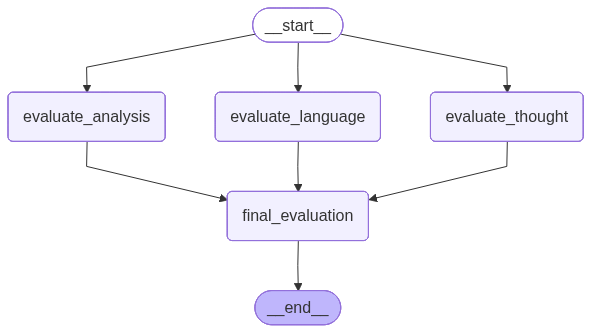

In [71]:
# Building the state graph
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_thought',evaluate_thought)
graph.add_node('final_evaluation',final_evaluation)


# create edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('evaluate_thought','final_evaluation')

graph.add_edge('final_evaluation', END)

graph.compile()

In [59]:
workflow=graph.compile()

initial_state={
    'essay':essay,

}

workflow.invoke(initial_state)

{'essay': '\n**Artificial Intelligence in India: Opportunities, Challenges, and the Road Ahead**\n\nArtificial Intelligence (AI) has emerged as one of the most transformative technologies of the 21st century, reshaping economies, governance, education, healthcare, and everyday life. In India, a country marked by vast population diversity, rapid digitization, and complex socio-economic challenges, AI holds immense promise. From improving public service delivery to boosting industrial productivity and fostering innovation, AI is increasingly seen as a key driver of India’s future growth. At the same time, its adoption raises critical questions related to ethics, employment, data privacy, and inclusivity. This essay explores the evolution, applications, opportunities, and challenges of AI in India, along with its future prospects.\n\nIndia’s engagement with AI has accelerated significantly over the past decade. The growth of digital infrastructure such as Aadhaar, Digital India, UPI, and 